# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [7]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

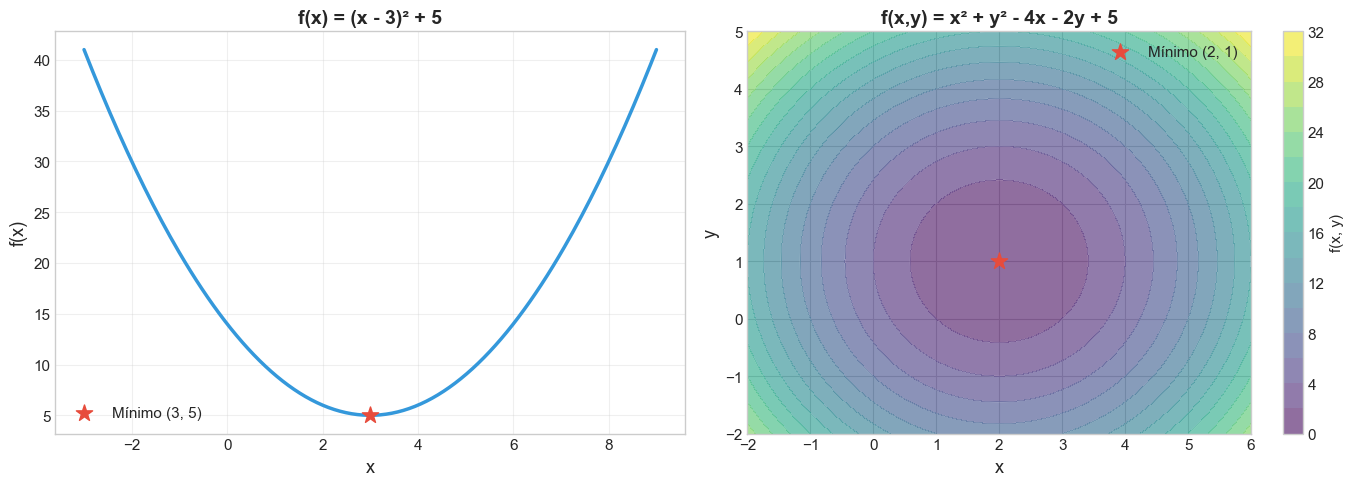

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [8]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [9]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False
    
    for i in range(max_iter):
        g = df_1d(x_actual)
        x_nuevo = x_actual - learning_rate * g #x= x- alpha *gradiente
        
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
        
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo 
            break
            
        x_actual = x_nuevo
        
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }
    
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa las variables:
    #    - x_actual = x_inicial
    #    - historial_x = [x_inicial]
    #    - historial_f = [f_1d(x_inicial)]
    #    - convergido = False
    
    # 2. Loop principal (max_iter iteraciones):
    #    a. Calcula el gradiente: g = df_1d(x_actual)
    #    b. Actualiza: x_nuevo = x_actual - learning_rate * g
    #    c. Guarda en historial
    #    d. Verifica convergencia: si |x_nuevo - x_actual| < tolerancia -> convergido
    #    e. Actualiza x_actual = x_nuevo
    
    # 3. Retorna el diccionario con resultados


### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [10]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


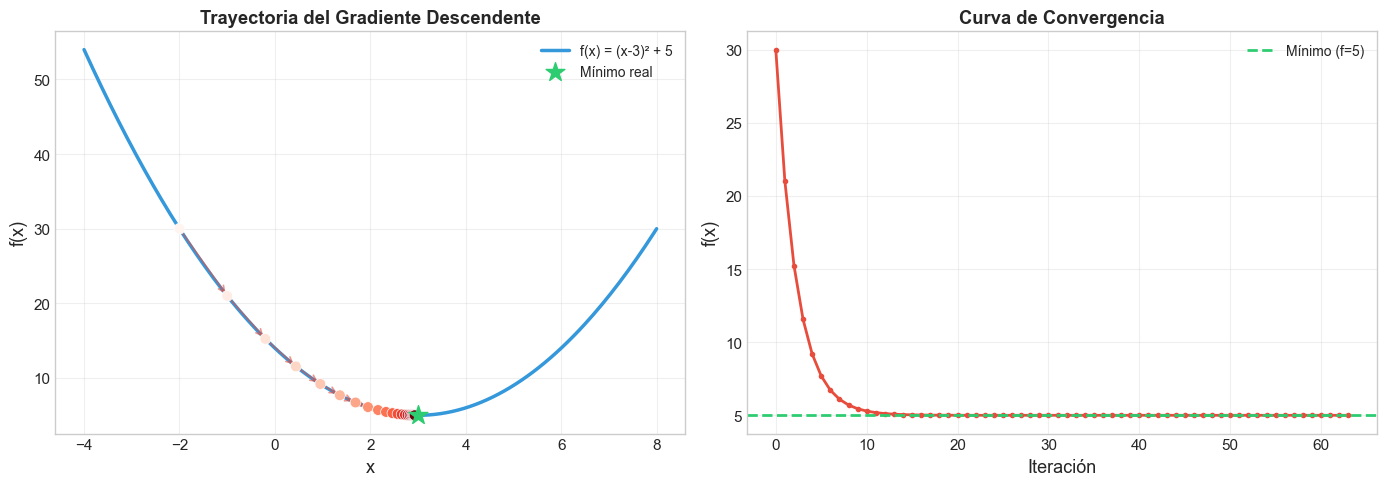

In [11]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [13]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

resultados_lr = []

# TU CODIGO: Para cada learning rate, ejecuta gradiente_descendente_1d
# y guarda los resultados en la lista resultados_lr

for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(x_inicial_prueba, lr, max_iter_prueba)
    resultados_lr.append(res)

print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Converg':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones      Converg
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

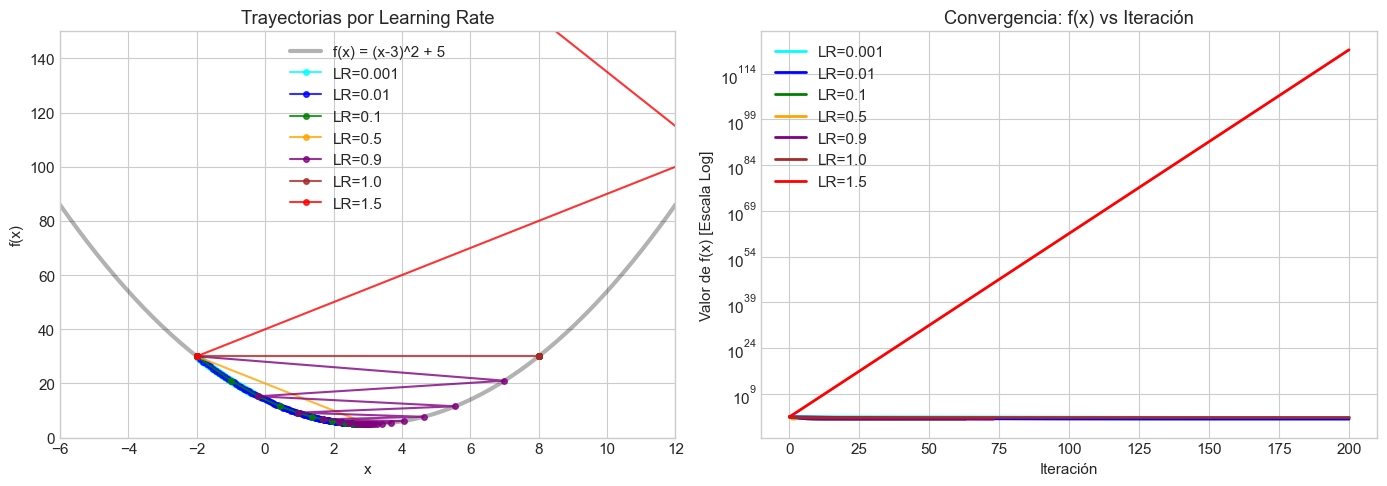

In [14]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================

# Crea dos graficas:
# 1. Trayectoria sobre f(x) para cada LR (con diferentes colores)
# 2. Curva de convergencia f(x) vs iteracion para cada LR

# Pista: usa fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pista: usa colores distintos para cada LR

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# f(x)
x_vals = np.linspace(-6, 12, 200)
y_vals = f_1d(x_vals)
axes[0].plot(x_vals, y_vals, label='f(x) = (x-3)^2 + 5', color='black', alpha=0.3, linewidth=3)
axes[0].set_title('Trayectorias por Learning Rate')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(0, 150)
axes[0].set_xlim(-6, 12)

#grafica de convergencia
axes[1].set_title('Convergencia: f(x) vs Iteración')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Valor de f(x) [Escala Log]')
axes[1].set_yscale('log') 

colores = ['cyan', 'blue', 'green', 'orange', 'purple', 'brown', 'red']

for i, res in enumerate(resultados_lr):
    lr = learning_rates_prueba[i]
    hist_x = res['historial_x']
    hist_f = res['historial_f']
    
    axes[0].plot(hist_x, hist_f, marker='o', markersize=4, linestyle='-', 
                 label=f'LR={lr}', color=colores[i], alpha=0.8)
    
    axes[1].plot(range(len(hist_f)), hist_f, 
                 label=f'LR={lr}', color=colores[i], linewidth=2)

axes[0].legend()
axes[1].legend()

plt.tight_layout()

**Responde estas preguntas basandote en tus experimentos:**

1. **Que pasa con un learning rate muy peque\u00f1o (0.001)?**
   - *Tu respuesta: Converge mas rapido*

2. **Por que consideras el mejor learning rate y por qu\u00e9?**
   - *Tu respuesta: Puede ser 0.5 porque converge de manera directa*

3. **Que pasa con learning rates >= 1.0?**
   - *Tu respuesta: Divergen*

4. **Por que un learning rate de exactamente 1.0 tiene un comportamiento especial para esta funcion?**
   - *Tu respuesta: Porque al evaluar con alpha = 1 y siendo x = -2 el movimiento va de -2 a 8 ain moverse a otro lado*

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [ ]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    x_actual, y_actual = x_inicial, y_inicial
    historial_x, historial_y = [x_inicial], [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False
    
    for _ in range(max_iter):
        g = grad_2d(x_actual, y_actual)
        
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
        
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            x_actual, y_actual = x_nuevo, y_nuevo
            break
            
        x_actual, y_actual = x_nuevo, y_nuevo
        
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }
"""
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa:
    #    - x_actual, y_actual = x_inicial, y_inicial
    #    - historiales vacios
    
    # 2. Loop principal:
    #    a. Calcula gradiente: g = grad_2d(x_actual, y_actual)  -> [gx, gy]
    #    b. Actualiza ambos parametros:
    #       x_nuevo = x_actual - lr * g[0]
    #       y_nuevo = y_actual - lr * g[1]
    #    c. Guarda en historiales
    #    d. Verifica convergencia: si ||gradiente|| < tolerancia -> convergido
    #       (norma del gradiente: np.linalg.norm(g))
    #    e. Actualiza x_actual, y_actual
    
    # 3. Retorna diccionario con resultados


### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [16]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


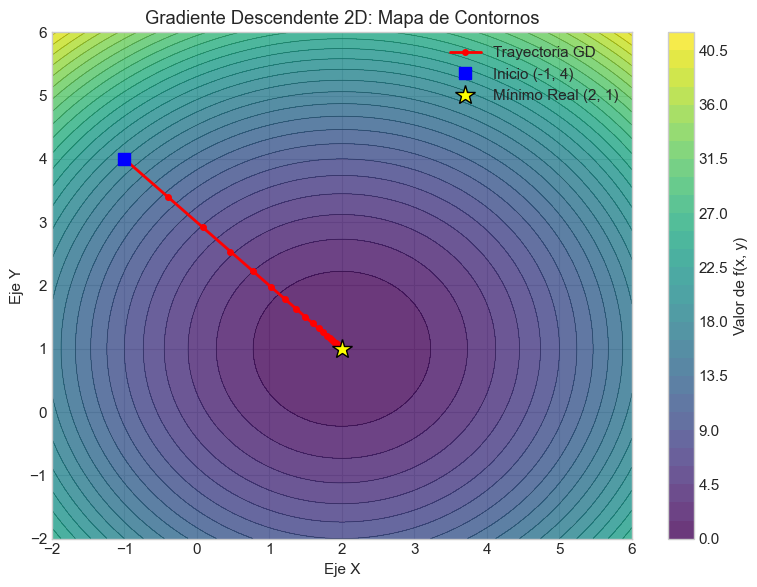

In [17]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
# 2. La trayectoria del gradiente descendente como puntos conectados
# 3. El punto de inicio marcado
# 4. El minimo real marcado con una estrella

# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria

#evaluar f(x,y)
x_val = np.linspace(-2, 6, 100)
y_val = np.linspace(-2, 6, 100)
X, Y = np.meshgrid(x_val, y_val)
Z = f_2d(X, Y) 

fig, ax = plt.subplots(figsize=(8, 6))

contour_filled = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
fig.colorbar(contour_filled, ax=ax, label='Valor de f(x, y)')
ax.contour(X, Y, Z, levels=30, colors='black', alpha=0.3, linewidths=0.5)

hx = resultado_2d['historial_x']
hy = resultado_2d['historial_y']

ax.plot(hx, hy, 'o-', color='red', markersize=4, linewidth=2, label='Trayectoria GD')
ax.plot(hx[0], hy[0], 's', color='blue', markersize=8, label='Inicio (-1, 4)')
ax.plot(2, 1, '*', color='yellow', markeredgecolor='black', markersize=15, label='Mínimo Real (2, 1)')

ax.set_title('Gradiente Descendente 2D: Mapa de Contornos')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.legend()

plt.tight_layout()

In [18]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

# TU CODIGO: ejecuta GD para cada punto inicial y muestra resultados
learning_rate_prueba = 0.1
max_iteraciones = 100

print(f"{'PUNTO INICIAL':<15} | {'PUNTO FINAL (x, y)':<25} | {'f(x,y)':<10} | {'ITERACIONES':<12} | {'CONVERGIÓ'}")
print("-" * 80)

for px, py in puntos_iniciales:
    res = gradiente_descendente_2d(
        x_inicial=px, 
        y_inicial=py, 
        learning_rate=learning_rate_prueba, 
        max_iter=max_iteraciones
    )
    
    p_ini_str = f"({px}, {py})"
    p_fin_str = f"({res['x_final']:.4f}, {res['y_final']:.4f})"
    f_val_str = f"{res['f_final']:.4f}"
    
    print(f"{p_ini_str:<15} | {p_fin_str:<25} | {f_val_str:<10} | {res['iteraciones']:<12} | {res['convergido']}")

print("-" * 80)



PUNTO INICIAL   | PUNTO FINAL (x, y)        | f(x,y)     | ITERACIONES  | CONVERGIÓ
--------------------------------------------------------------------------------
(-1.0, 4.0)     | (2.0000, 1.0000)          | 0.0000     | 73           | True
(5.0, -1.0)     | (2.0000, 1.0000)          | 0.0000     | 72           | True
(0.0, 0.0)      | (2.0000, 1.0000)          | 0.0000     | 70           | True
--------------------------------------------------------------------------------


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [25]:
# ============================================================
# TU CODIGO AQUI: Genera el DataFrame con todos los experimentos
# ============================================================

# 1. Ejecuta TODOS los experimentos:
#    - 1D: learning_rates [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
#           desde x=-2.0
#    - 2D: learning_rates [0.001, 0.01, 0.1, 0.5]
#           desde (-1, 4), (5, -1), (0, 0)

# 2. Crea el DataFrame

# 3. Guardalo como CSV

# df_experimentos = pd.DataFrame(...)
# df_experimentos.to_csv('experimentos_gd.csv', index=False)

datos_experimentos = []

#Para 1D
lrs_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_ini_1d = -2.0
max_iteraciones = 200  

for lr in lrs_1d:
    res = gradiente_descendente_1d(x_inicial=x_ini_1d, learning_rate=lr, max_iter=max_iteraciones)
    datos_experimentos.append({
        'dimension': '1D',
        'learning_rate': lr,
        'x_inicial': x_ini_1d,
        'y_inicial': np.nan,
        'x_final': res['x_final'],
        'y_final': np.nan,
        'f_final': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })

#Para 2D 
lrs_2d = [0.001, 0.01, 0.1, 0.5]
puntos_ini_2d = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for px, py in puntos_ini_2d:
    for lr in lrs_2d:
        res = gradiente_descendente_2d(x_inicial=px, y_inicial=py, learning_rate=lr, max_iter=max_iteraciones)
        datos_experimentos.append({
            'dimension': '2D',
            'learning_rate': lr,
            'x_inicial': px,
            'y_inicial': py,
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'f_final': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })

df_experimentos = pd.DataFrame(datos_experimentos)
df_experimentos.to_csv('experimentos_gd.csv', index=False)

In [26]:
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
dimension  learning_rate  x_inicial  y_inicial       x_final   y_final       f_final  iteraciones  convergido
       1D          0.001       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
       1D          0.010       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
       1D          0.100       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           63        True
       1D          0.500       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
       1D          0.900       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           73        True
       1D          1.000       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
       1D          1.500       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
       2D          0.001       -1.0        4.0 -1.015484e-02  3.010155  8.081445e+00  

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **Cual es el rango de learning rates que funciona bien para estas funciones?**
   - *Tu respuesta: O.5 porque converge rapido para las dos *

2. **Por que punto inicial afecta si el algoritmo converge? Como afecta cuantas iteraciones necesita?**
   - *Tu respuesta: El punto inicial afecta porque si es muy lejano entonces seran mas iteraciones, y el numero de iteraciones afecta porque si son demasiadas y no converge entonces es un gasto computacional inecesario, y si son pocas y no converge entonces se debe aumentar porque tal vez esta limitando al algoritmo*

3. **Que puede pasar  si la funcion tuviera multiples minimos locales? (piensa en una funcion como `sin(x) + x\u00b2/10`)**
   - *Tu respuesta: Entonces no se puede asegurar que el minimo que se encuentre sea global*

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la funcion de costo es como `f(x,y)`. Por que es importante elegir bien el learning rate al entrenar?**
   - *Tu respuesta: Porque un learning rate incorrecto puede conllevar a muchas iteraciones o que diverga *

5. **Que ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *Tu respuesta: Se asegura que se esta disminuyendo el error poco a poco*

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [21]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

#datos y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [22]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    w = 0.0
    b = 0.0
    
    historial_loss = []
    historial_w = []
    historial_b = []
    
    n_muestras = len(X)
    
    for epoch in range(epochs):
        indices = np.random.permutation(n_muestras) #mezclar aleatoriamente
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, n_muestras, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            
            current_batch_size = len(X_batch)
            y_pred = w * X_batch + b
            error = y_batch - y_pred
            
            dw = (-2 / current_batch_size) * np.sum(error * X_batch) #calculo de gradientes y promedio
            db = (-2 / current_batch_size) * np.sum(error)
            
            w = w - learning_rate * dw
            b = b - learning_rate * db
            
        y_pred_total = w * X + b
        mse = np.mean((y - y_pred_total) ** 2)
        
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)
        
    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa w = 0, b = 0
    # 2. Para cada epoch:
    #    a. Mezcla los indices aleatoriamente
    #    b. Para cada mini-batch:
    #       - Selecciona batch_size muestras
    #       - Calcula prediccion: y_pred = w * X_batch + b
    #       - Calcula error: error = y_batch - y_pred
    #       - Calcula gradientes:
    #           dw = -2/batch_size * sum(error * X_batch)
    #           db = -2/batch_size * sum(error)
    #       - Actualiza: w = w - lr * dw, b = b - lr * db
    #    c. Calcula MSE del epoch completo y guarda en historial


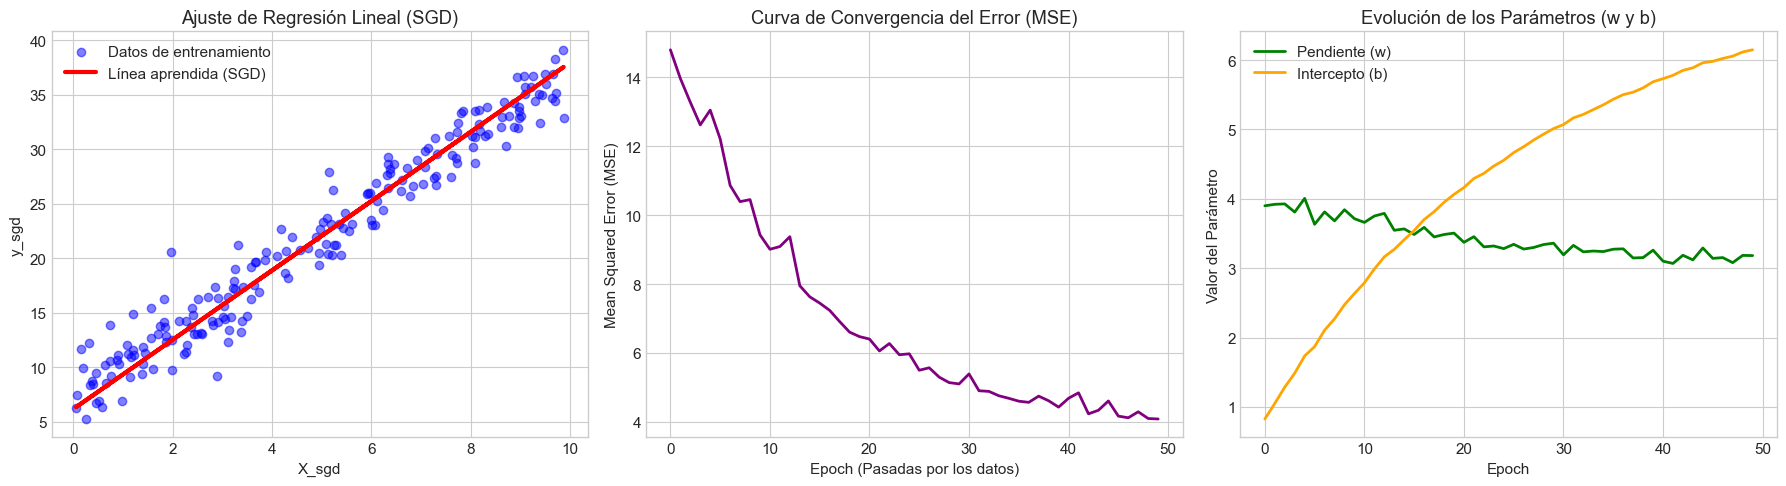

In [23]:
# Ejecuta SGD y visualiza resultados

# resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# TU CODIGO: Crea graficas comparando:
# 1. Datos + linea aprendida por SGD vs linea real
# 2. Curva de loss por epoch
# 3. Evolucion de w y b por epoch
# Ejecuta SGD y visualiza resultados
resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# TU CODIGO: Crea graficas comparando:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_sgd, y_sgd, color='blue', alpha=0.5, label='Datos de entrenamiento')
y_pred_sgd = resultado_sgd['w_final'] * X_sgd + resultado_sgd['b_final']
axes[0].plot(X_sgd, y_pred_sgd, color='red', linewidth=3, label='Línea aprendida (SGD)')

axes[0].set_title('Ajuste de Regresión Lineal (SGD)')
axes[0].set_xlabel('X_sgd')
axes[0].set_ylabel('y_sgd')
axes[0].legend()

loss_hist = resultado_sgd['historial_loss']
axes[1].plot(range(len(loss_hist)), loss_hist, color='purple', linewidth=2)
axes[1].set_title('Curva de Convergencia del Error (MSE)')
axes[1].set_xlabel('Epoch (Pasadas por los datos)')
axes[1].set_ylabel('Mean Squared Error (MSE)')

w_hist = resultado_sgd['historial_w']
b_hist = resultado_sgd['historial_b']

axes[2].plot(range(len(w_hist)), w_hist, color='green', linewidth=2, label='Pendiente (w)')
axes[2].plot(range(len(b_hist)), b_hist, color='orange', linewidth=2, label='Intercepto (b)')

axes[2].set_title('Evolución de los Parámetros (w y b)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Valor del Parámetro')
axes[2].legend()

plt.tight_layout()
plt.show()



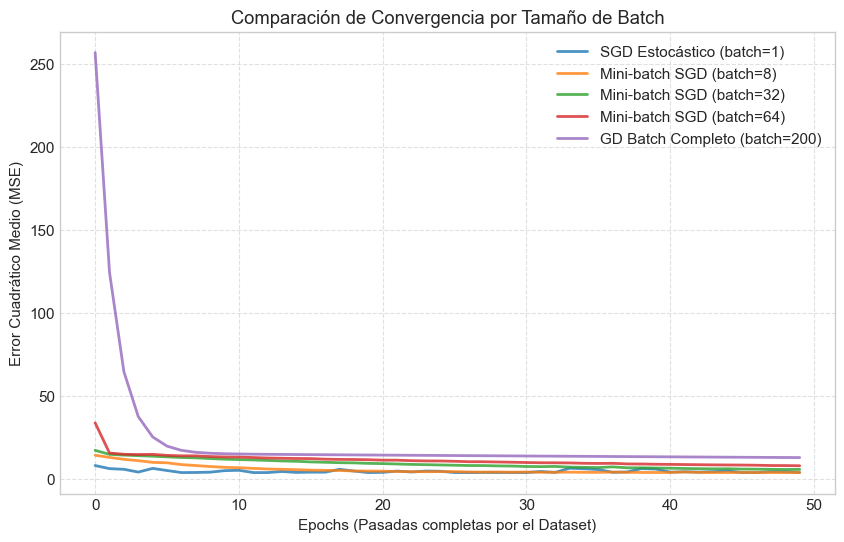

In [29]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

# batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

# TU CODIGO: ejecuta para cada batch_size y compara convergencia

# ============================================================
# EXTRA: Compara GD vs SGD con diferentes batch_sizes
# ============================================================
# ============================================================
# EXTRA: Compara GD vs SGD con diferentes batch_sizes
# ============================================================
n_datos = len(X_sgd)
batch_sizes = [1, 8, 32, 64, n_datos]  

plt.figure(figsize=(10, 6))
learning_rate_prueba = 0.005 
epochs_prueba = 50

for bs in batch_sizes: # para los tamaños
    res = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=learning_rate_prueba, 
                               epochs=epochs_prueba, batch_size=bs)
    
    if bs == 1:
        etiqueta = 'SGD Estocástico (batch=1)'
    elif bs == n_datos:
        etiqueta = f'GD Batch Completo (batch={n_datos})'
    else:
        etiqueta = f'Mini-batch SGD (batch={bs})'
        
    plt.plot(range(len(res['historial_loss'])), res['historial_loss'], 
             label=etiqueta, linewidth=2, alpha=0.8)

plt.title('Comparación de Convergencia por Tamaño de Batch')

plt.xlabel('Epochs (Pasadas completas por el Dataset)') 
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend(loc='upper right') 
plt.grid(True, linestyle='--', alpha=0.6) 

plt.show() 


**Preguntas Bonus:**

1. **Que diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *Tu respuesta: SGD converge mas rapido pero tiene mas ruido, y GD tara en converger pero lo hace mas directo *

2. **El batch_size te dio los mejores resultados? Por que?**
   - *Tu respuesta: 8 y 32 porque convergen rapido y con menos ruido*

3. **Por que la curva de los de SGD es masruidosa que la de GD?**
   - *Tu respuesta: porque SGD va evaluando de un dato a la vez, y GD promedia el error antes de dar el otro paso*

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_